In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler # Importamos MinMaxScaler
from sklearn.model_selection import train_test_split


#Se definen los parametros con los que se simulan los datos

La velocidad terminal (vt) calculada es: 8.08 m/s

Primeros 5 registros del DataFrame:
   Tiempo (s)  Velocidad (m/s)
0         0.0         0.000000
1         0.1         0.975226
2         0.2         1.922467
3         0.3         2.816859
4         0.4         3.639072

Últimos 5 registros del DataFrame:
     Tiempo (s)  Velocidad (m/s)
196        19.6         8.082904
197        19.7         8.082904
198        19.8         8.082904
199        19.9         8.082904
200        20.0         8.082904


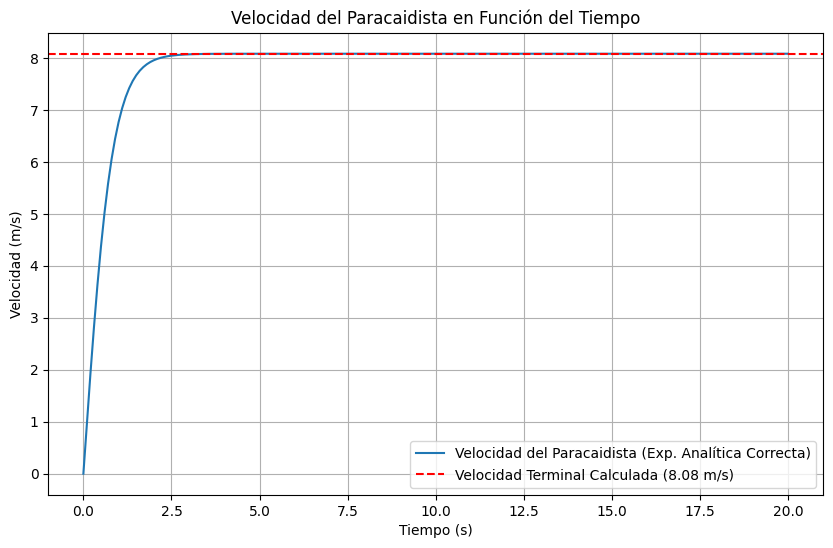

In [ ]:
# --- Parámetros del problema ---
m = 80.0  # Masa en kg
k = 12.0  # Coeficiente de fricción en kg/s
g = 9.8   # Aceleración de la gravedad en m/s^2

# --- Parámetros de la simulación ---
ti = 0.0  # Tiempo inicial en s
tf = 20.0 # Tiempo final en s
h = 0.1   # Paso de tiempo en s
n = int((tf - ti) / h) + 1 # Número de puntos de tiempo

# --- Cálculos iniciales ---
vt = np.sqrt((m * g) / k) # Velocidad terminal
v0 = 0.0  # Velocidad inicial (parte del reposo)

print(f"La velocidad terminal (vt) calculada es: {vt:.2f} m/s")

# --- Generar el arreglo de tiempo ---
tiempo = np.linspace(ti, tf, n)

# --- Calcular la velocidad para cada punto de tiempo usando la solución analítica con exponenciales ---
# Aquí corregimos la expresión para que sea equivalente a vt * tanh((g / vt) * tiempo)
exp_arg = (g / vt) * tiempo # Este es el 'x' en tanh(x)

# Aplicamos la definición de tanh(x) = (e^x - e^-x) / (e^x + e^-x), y luego multiplicamos por vt
velocidad = vt * ( (np.exp(exp_arg) - np.exp(-exp_arg)) / (np.exp(exp_arg) + np.exp(-exp_arg)) )

# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Mostrar los primeros y últimos valores del DataFrame (opcional) ---
print("\nPrimeros 5 registros del DataFrame:")
print(entrada.head())
print("\nÚltimos 5 registros del DataFrame:")
print(entrada.tail())

# --- Crear la gráfica ---
plt.figure(figsize=(10, 6)) # Tamaño de la figura
plt.plot(entrada['Tiempo (s)'], entrada['Velocidad (m/s)'], label='Velocidad del Paracaidista (Exp. Analítica Correcta)')
plt.axhline(y=vt, color='r', linestyle='--', label=f'Velocidad Terminal Calculada ({vt:.2f} m/s)') # Línea de velocidad terminal
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title('Velocidad del Paracaidista en Función del Tiempo')
plt.grid(True) # Rejilla en la gráfica
plt.legend() # Mostrar la leyenda
plt.show() # Mostrar la gráfica

La velocidad terminal (vt) calculada es: 8.08 m/s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - loss: 1.3148 - mean_absolute_error: 1.1317 - val_loss: 1.3363 - val_mean_absolute_error: 1.1559
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.2455 - mean_absolute_error: 1.0998 - val_loss: 1.2770 - val_mean_absolute_error: 1.1299
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1925 - mean_absolute_error: 1.0748 - val_loss: 1.2189 - val_mean_absolute_error: 1.1039
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1475 - mean_absolute_error: 1.0591 - val_loss: 1.1621 - val_mean_absolute_error: 1.0779
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1128 - mean_absolute_error: 1.0455 - val_loss: 1.1068 - val_mean_absolute_error: 1.0519
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0296 - mean_absolute_error: 0.9989 - val_loss: 1.0532 - val_mean_absolute_error: 1.0261
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9919 - mean_absolute_error: 0.9830 - val_loss: 1.00

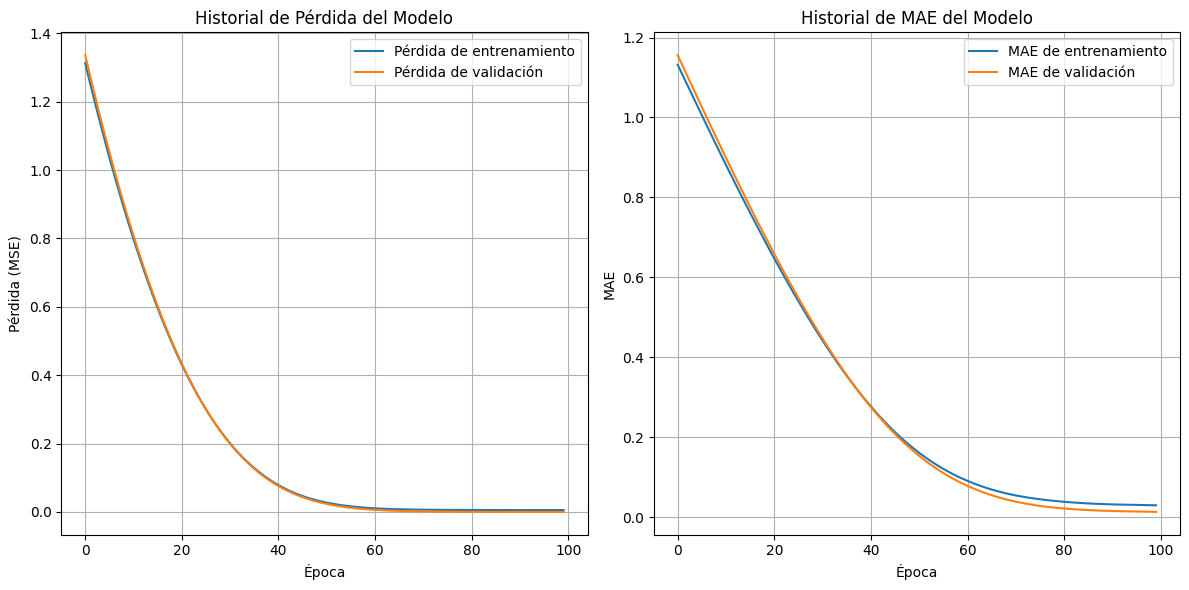

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


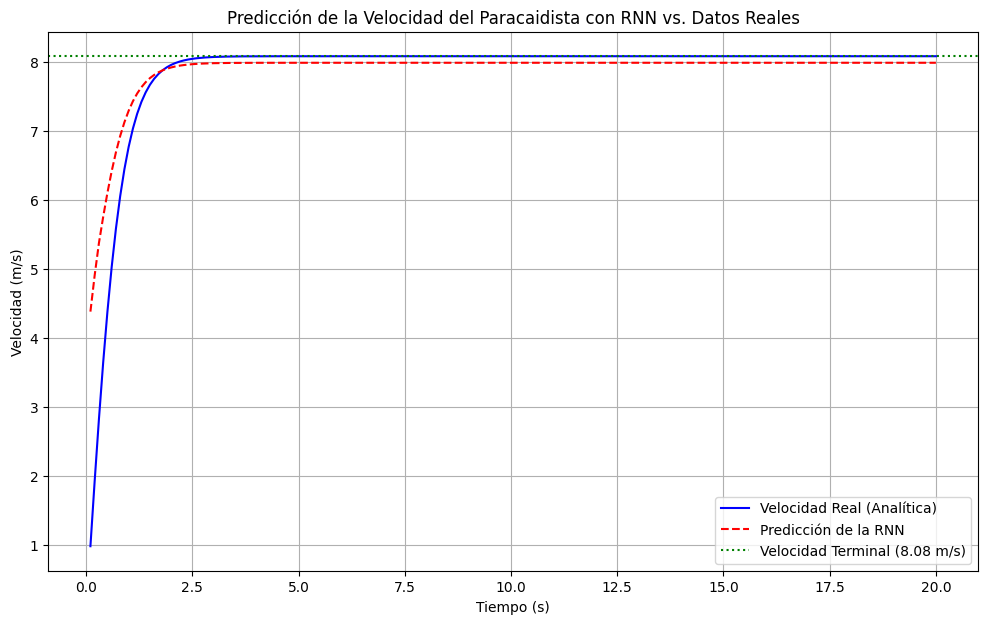

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.metrics import MeanAbsoluteError # Importar MAE

# --- Parámetros del problema ---
m = 80.0  # Masa en kg
k = 12.0  # Coeficiente de fricción en kg/s
g = 9.8   # Aceleración de la gravedad en m/s^2

# --- Parámetros de la simulación ---
ti = 0.0  # Tiempo inicial en s
tf = 20.0 # Tiempo final en s
h = 0.1   # Paso de tiempo en s
n = int((tf - ti) / h) + 1 # Número de puntos de tiempo

# --- Cálculos iniciales ---
vt = np.sqrt((m * g) / k) # Velocidad terminal
v0 = 0.0  # Velocidad inicial (parte del reposo)

print(f"La velocidad terminal (vt) calculada es: {vt:.2f} m/s")

# --- Generar el arreglo de tiempo ---
tiempo = np.linspace(ti, tf, n)

# --- Calcular la velocidad para cada punto de tiempo usando la solución analítica con exponenciales ---
exp_arg = (g / vt) * tiempo
velocidad = vt * ( (np.exp(exp_arg) - np.exp(-exp_arg)) / (np.exp(exp_arg) + np.exp(-exp_arg)) )

# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Preparación de los datos para la RNN ---
X = entrada['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una SimpleRNN con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (RNN) ---
modelrelu = Sequential()
modelrelu.add(SimpleRNN(5, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
modelrelu.add(Dense(1))

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelrelu.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelrelu.summary()

# --- Entrenamiento del modelo ---
history = modelrelu.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelrelu.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelrelu.predict(X_scaled) # Corregido: Usar modelrelu
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la RNN', color='red', linestyle='--')
plt.axhline(y=vt, color='green', linestyle=':', label=f'Velocidad Terminal ({vt:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con RNN vs. Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

#Usando LSTM

La velocidad terminal (vt) calculada es: 8.08 m/s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - loss: 0.9720 - val_loss: 0.9562
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.9002 - val_loss: 0.8915
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8271 - val_loss: 0.8289
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7884 - val_loss: 0.7683
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7237 - val_loss: 0.7096
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6563 - val_loss: 0.6525
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6133 - val_loss: 0.5967
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5487 - val_loss: 0.5425
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5075 - val_loss: 0.4896
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4525 - val_loss: 0.4383
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3964 - val_loss: 0.3888
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3567 - val_l

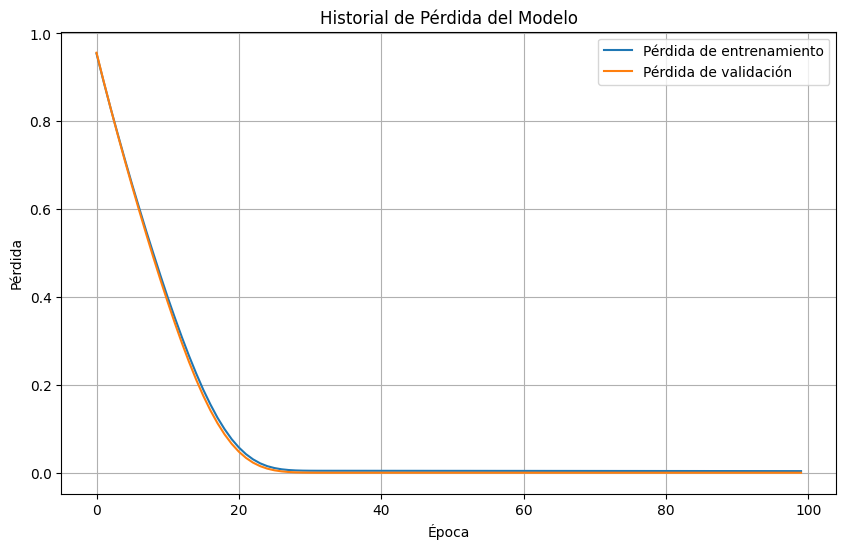

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


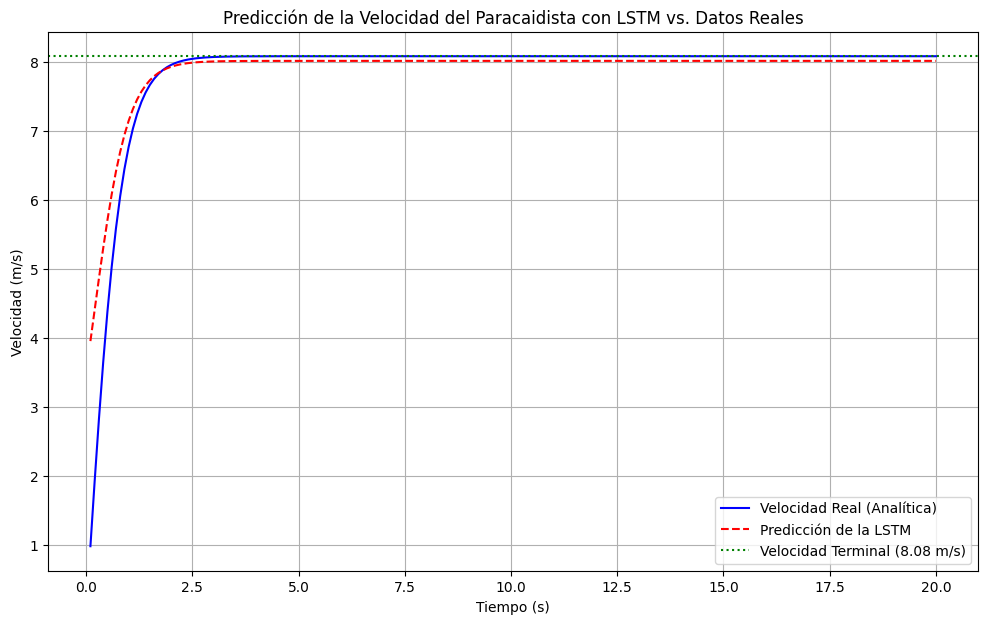

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense # Importar LSTM

# --- Parámetros del problema ---
m = 80.0  # Masa en kg
k = 12.0  # Coeficiente de fricción en kg/s
g = 9.8   # Aceleración de la gravedad en m/s^2

# --- Parámetros de la simulación ---
ti = 0.0  # Tiempo inicial en s
tf = 20.0 # Tiempo final en s
h = 0.1   # Paso de tiempo en s
n = int((tf - ti) / h) + 1 # Número de puntos de tiempo

# --- Cálculos iniciales ---
vt = np.sqrt((m * g) / k) # Velocidad terminal
v0 = 0.0  # Velocidad inicial (parte del reposo)

print(f"La velocidad terminal (vt) calculada es: {vt:.2f} m/s")

# --- Generar el arreglo de tiempo ---
tiempo = np.linspace(ti, tf, n)

# --- Calcular la velocidad para cada punto de tiempo usando la solución analítica con exponenciales ---
exp_arg = (g / vt) * tiempo
velocidad = vt * ( (np.exp(exp_arg) - np.exp(-exp_arg)) / (np.exp(exp_arg) + np.exp(-exp_arg)) )

# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Preparación de los datos para la RNN ---
X = entrada['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una LSTM con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (LSTM) ---
modelLSTM = Sequential()
modelLSTM.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]))) # Mantener relu en la capa LSTM
modelLSTM.add(Dense(1)) # ¡QUITAR LA FUNCIÓN DE ACTIVACIÓN (tanh) DE LA CAPA DE SALIDA!
modelLSTM.compile(optimizer='adam', loss='mean_squared_error')
# Compilación del modelo

# Resumen del modelo
modelLSTM.summary() # Corregido: Llamar a summary() del modelo correcto

# --- Entrenamiento del modelo ---
# Aumentar las épocas para permitir que la LSTM aprenda mejor
history = modelLSTM.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
loss = modelLSTM.evaluate(X_test, y_test, verbose=0)
print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')

# --- Visualización del historial de entrenamiento ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelLSTM.predict(X_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la LSTM', color='red', linestyle='--')
plt.axhline(y=vt, color='green', linestyle=':', label=f'Velocidad Terminal ({vt:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con LSTM vs. Datos Reales') # Actualizado el título
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

La velocidad terminal (vt) calculada es: 8.08 m/s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.9167 - mean_absolute_error: 0.9451 - val_loss: 0.9143 - val_mean_absolute_error: 0.9561
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8627 - mean_absolute_error: 0.9200 - val_loss: 0.8579 - val_mean_absolute_error: 0.9261
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8008 - mean_absolute_error: 0.8828 - val_loss: 0.8032 - val_mean_absolute_error: 0.8961
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7539 - mean_absolute_error: 0.8574 - val_loss: 0.7499 - val_mean_absolute_error: 0.8659
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7043 - mean_absolute_error: 0.8267 - val_loss: 0.6977 - val_mean_absolute_error: 0.8352
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6629 - mean_absolute_error: 0.8058 - val_loss: 0.6463 - val_mean_absolute_error: 0.8038
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6117 - mean_absolute_error: 0.7745 - val_loss: 0.595

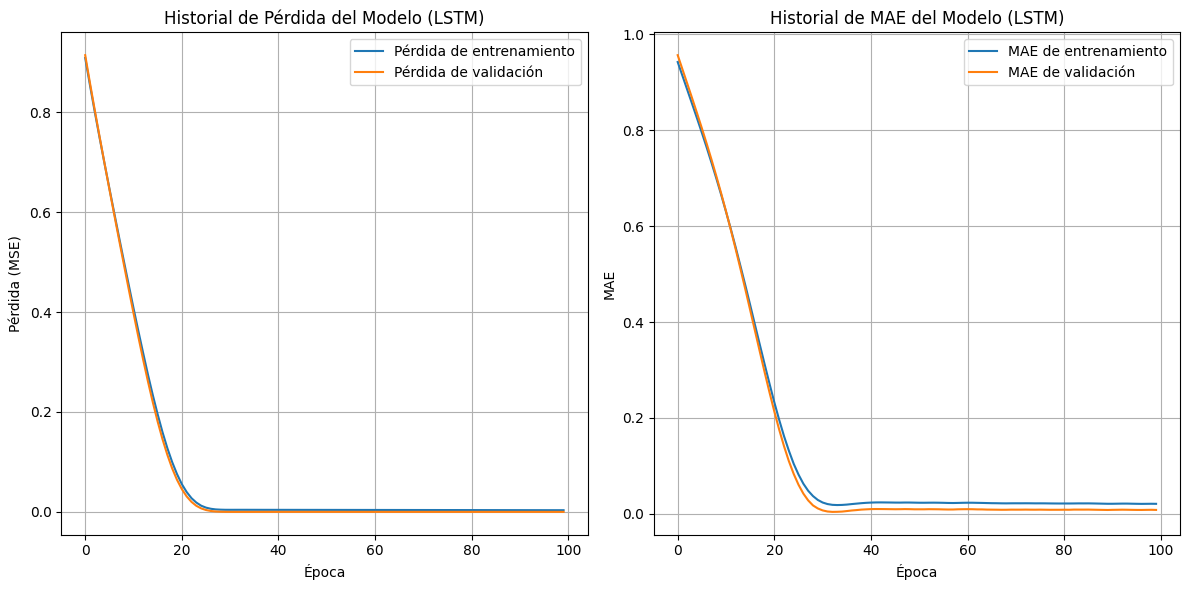

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


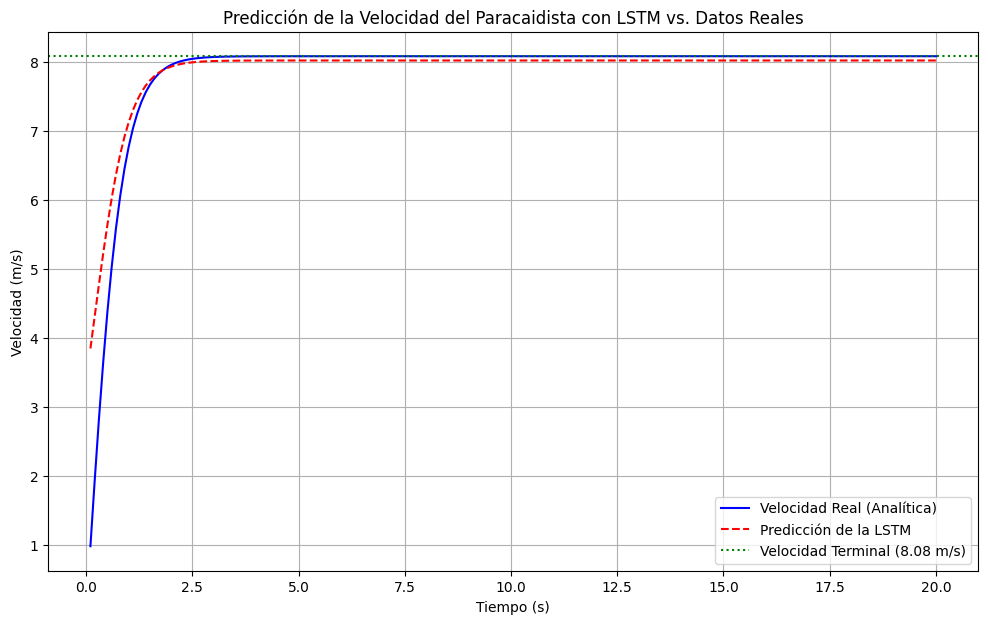

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense # Importar LSTM
from tensorflow.keras.metrics import MeanAbsoluteError # Importar MAE

# --- Parámetros del problema ---
m = 80.0  # Masa en kg
k = 12.0  # Coeficiente de fricción en kg/s
g = 9.8   # Aceleración de la gravedad en m/s^2

# --- Parámetros de la simulación ---
ti = 0.0  # Tiempo inicial en s
tf = 20.0 # Tiempo final en s
h = 0.1   # Paso de tiempo en s
n = int((tf - ti) / h) + 1 # Número de puntos de tiempo

# --- Cálculos iniciales ---
vt = np.sqrt((m * g) / k) # Velocidad terminal
v0 = 0.0  # Velocidad inicial (parte del reposo)

print(f"La velocidad terminal (vt) calculada es: {vt:.2f} m/s")

# --- Generar el arreglo de tiempo ---
tiempo = np.linspace(ti, tf, n)

# --- Calcular la velocidad para cada punto de tiempo usando la solución analítica con exponenciales ---
exp_arg = (g / vt) * tiempo
velocidad = vt * ( (np.exp(exp_arg) - np.exp(-exp_arg)) / (np.exp(exp_arg) + np.exp(-exp_arg)) )

# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Preparación de los datos para la RNN ---
X = entrada['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una LSTM con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (LSTM) ---
modelLSTM = Sequential()
# Nota: La activación 'tanh' en la capa LSTM interna es común y a menudo efectiva.
# El punto crítico es la capa de salida.
modelLSTM.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
modelLSTM.add(Dense(1)) # ¡Importante: SIN FUNCIÓN DE ACTIVACIÓN en la capa de salida para regresión!

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelLSTM.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelLSTM.summary()

# --- Entrenamiento del modelo ---
# Aumentar las épocas para permitir que la LSTM aprenda mejor
history = modelLSTM.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelLSTM.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento (Pérdida y MAE) ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelLSTM.predict(X_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la LSTM', color='red', linestyle='--')
plt.axhline(y=vt, color='green', linestyle=':', label=f'Velocidad Terminal ({vt:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con LSTM vs. Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

###5.Preguntas
- ¿Hasta qué punto la red recurrente logra capturar el comportamiento físico del sistema?
------------------------------
#####La SimpleRNN logra ajustar muy exitosamente el comportamiento aunque su perdida es algo alta, esto tambien puede deberse al uso de pocas neuronas.
------------------------------
- ¿Qué representa la velocidad terminal y cómo la identifica el modelo?

------------------------------
#####La velocidad terminal implica un punto de cambio cero en la funcion, el modelo reconoce que llegado a un punto no cambia el resultado pero le cuesta ser preciso con el punto exacto donde ocurre, por lo que llega a una velocidad terminal menor.
------------------------------

- ¿Qué ventajas ofrece una red recurrente frente a una red densa tradicional?

------------------------------
#####La red tradicional tendria inmensos problemas para aprender el comportamiento del sistema una vez ha llegado a su velocidad terminal, pues no tendria como darse cuenta de que lleva tiempo en dicho comportamiento, se necesitaria overfitting para que lo predijera.
------------------------------

- ¿Cómo cambiarían los resultados si los datos fueran medidos experimentalmente con ruido?

------------------------------
#####En dado caso la red podria aprenderse los cambios aleatorios del comportamiento y mostrar que la velocidad terminal cambia ligeramente con saltos pequeños y se mantiene alrededor de un punto
------------------------------

Comparacion SimpleRNN VS LSTM

-

#Comportamiento para datos distintos

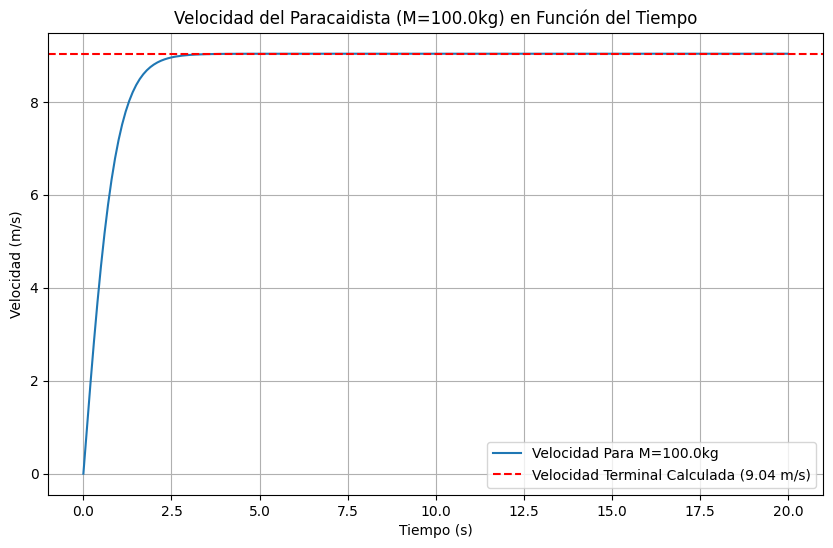

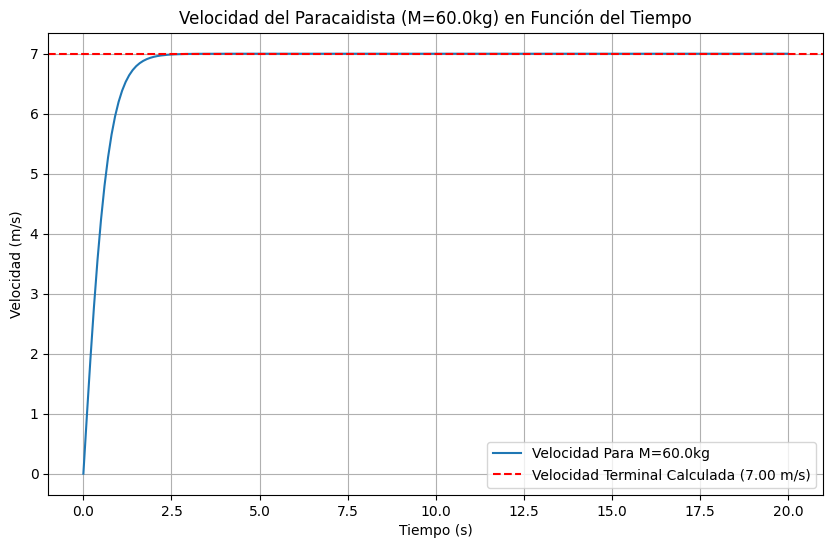

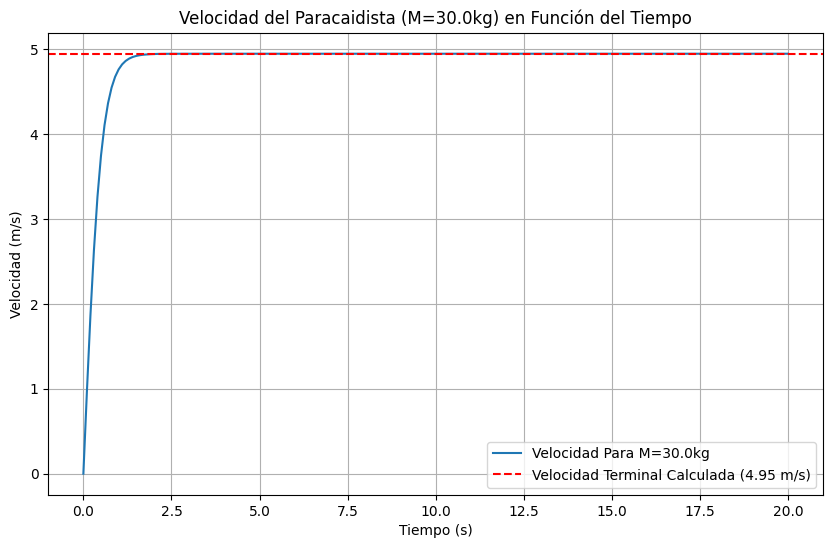

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parámetros físicos ---
m1 = 100.0  # Masa en kg
m2 = 60.0
m3 = 30.0
k = 12.0  # Coeficiente de fricción en kg/s
g = 9.8   # Aceleración de la gravedad en m/s^2

# --- Parámetros de la simulación ---
ti = 0.0  # Tiempo inicial en s
tf = 20.0 # Tiempo final en s
h = 0.1   # Paso de tiempo en s
n = int((tf - ti) / h) + 1 # Número de puntos de tiempo

# --- Cálculos iniciales ---
vt1 = np.sqrt((m1 * g) / k) # Velocidad terminal para m1
vt2 = np.sqrt((m2 * g) / k) # Velocidad terminal para m2
vt3 = np.sqrt((m3 * g) / k) # Velocidad terminal para m3

v0 = 0.0  # Velocidad inicial (parte del reposo)

tiempo = np.linspace(ti, tf, n)

# Expresiones para los argumentos de tanh(x) para cada masa
exp_arg1 = (g / vt1) * tiempo
exp_arg2 = (g / vt2) * tiempo
exp_arg3 = (g / vt3) * tiempo

# Aplicamos la definición de tanh(x) = (e^x - e^-x) / (e^x + e^-x), y luego multiplicamos por vt
velocidad1 = vt1 * ((np.exp(exp_arg1) - np.exp(-exp_arg1)) / (np.exp(exp_arg1) + np.exp(-exp_arg1)))
velocidad2 = vt2 * ((np.exp(exp_arg2) - np.exp(-exp_arg2)) / (np.exp(exp_arg2) + np.exp(-exp_arg2)))
velocidad3 = vt3 * ((np.exp(exp_arg3) - np.exp(-exp_arg3)) / (np.exp(exp_arg3) + np.exp(-exp_arg3)))

# --- Crear los DataFrames ---
# Es importante que cada DataFrame use su respectiva `velocidadX`
entrada1 = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad1})
entrada2 = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad2})
entrada3 = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad3})

# --- Crear la gráfica para la masa 1 ---
plt.figure(figsize=(10, 6)) # Tamaño de la figura
plt.plot(entrada1['Tiempo (s)'], entrada1['Velocidad (m/s)'], label=f'Velocidad Para M={m1}kg')
plt.axhline(y=vt1, color='r', linestyle='--', label=f'Velocidad Terminal Calculada ({vt1:.2f} m/s)') # Línea de velocidad terminal
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title(f'Velocidad del Paracaidista (M={m1}kg) en Función del Tiempo')
plt.grid(True) # Rejilla en la gráfica
plt.legend() # Mostrar la leyenda
plt.show() # Mostrar la gráfica

# --- Crear la gráfica para la masa 2 ---
plt.figure(figsize=(10, 6)) # Tamaño de la figura
# AQUÍ ESTABA EL ERROR: Cambiado de entrada1['Velocidad (m/s)'] a entrada2['Velocidad (m/s)']
plt.plot(entrada2['Tiempo (s)'], entrada2['Velocidad (m/s)'], label=f'Velocidad Para M={m2}kg')
plt.axhline(y=vt2, color='r', linestyle='--', label=f'Velocidad Terminal Calculada ({vt2:.2f} m/s)') # Línea de velocidad terminal
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title(f'Velocidad del Paracaidista (M={m2}kg) en Función del Tiempo')
plt.grid(True) # Rejilla en la gráfica
plt.legend() # Mostrar la leyenda
plt.show() # Mostrar la gráfica

# --- Crear la gráfica para la masa 3 ---
plt.figure(figsize=(10, 6)) # Tamaño de la figura
# AQUÍ ESTABA EL ERROR: Cambiado de entrada1['Velocidad (m/s)'] a entrada3['Velocidad (m/s)']
plt.plot(entrada3['Tiempo (s)'], entrada3['Velocidad (m/s)'], label=f'Velocidad Para M={m3}kg')
plt.axhline(y=vt3, color='r', linestyle='--', label=f'Velocidad Terminal Calculada ({vt3:.2f} m/s)') # Línea de velocidad terminal
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title(f'Velocidad del Paracaidista (M={m3}kg) en Función del Tiempo')
plt.grid(True) # Rejilla en la gráfica
plt.legend() # Mostrar la leyenda
plt.show() # Mostrar la gráfica

#Modelo Simple RNN Para una masa $M = 100kg$

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - loss: 1.0682 - mean_absolute_error: 1.0203 - val_loss: 1.0838 - val_mean_absolute_error: 1.0408
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0363 - mean_absolute_error: 1.0077 - val_loss: 1.0436 - val_mean_absolute_error: 1.0213
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9776 - mean_absolute_error: 0.9735 - val_loss: 1.0038 - val_mean_absolute_error: 1.0017
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9341 - mean_absolute_error: 0.9493 - val_loss: 0.9645 - val_mean_absolute_error: 0.9818
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9055 - mean_absolute_error: 0.9371 - val_loss: 0.9255 - val_mean_absolute_error: 0.9618
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8779 - mean_absolute_error: 0.9242 - val_loss: 0.8871 - val_mean_absolute_error: 0.9417
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8262 - mean_absolute_error: 0.8961 - val_loss: 0.84

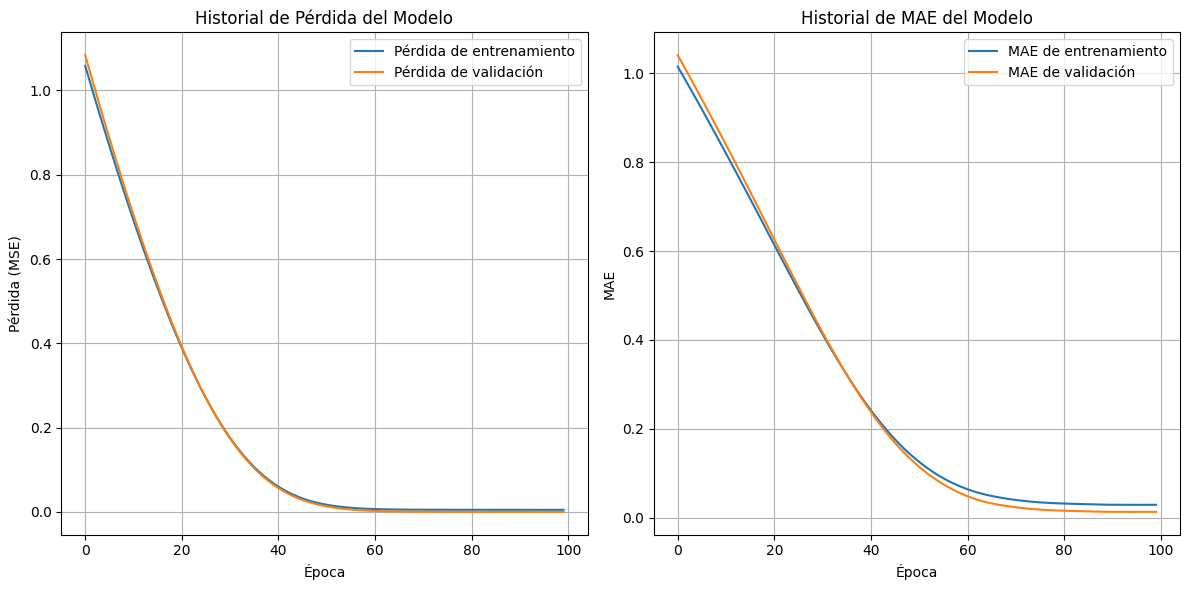

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


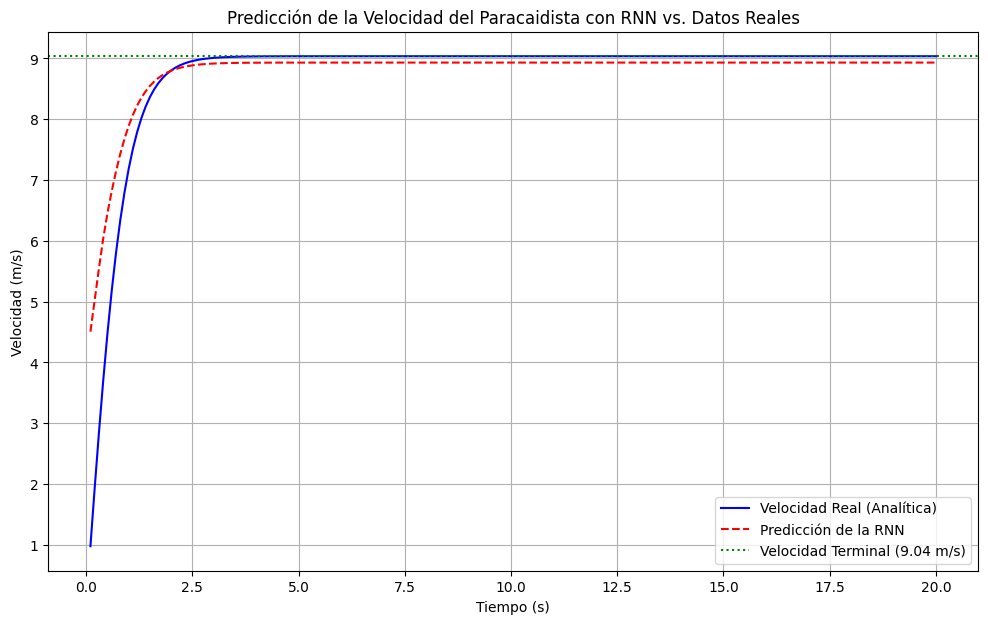

In [ ]:
# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Preparación de los datos para la RNN ---
X = entrada1['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada1['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una SimpleRNN con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (RNN) ---
modelrelu = Sequential()
modelrelu.add(SimpleRNN(10, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
modelrelu.add(Dense(1))

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelrelu.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelrelu.summary()

# --- Entrenamiento del modelo ---
history = modelrelu.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelrelu.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelrelu.predict(X_scaled) # Corregido: Usar modelrelu
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad1[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la RNN', color='red', linestyle='--')
plt.axhline(y=vt1, color='green', linestyle=':', label=f'Velocidad Terminal ({vt1:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con RNN vs. Datos Reales para M=100')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

#Modelo SimpleRNN para $M=60kg$

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - loss: 0.1671 - mean_absolute_error: 0.4065 - val_loss: 0.1552 - val_mean_absolute_error: 0.3940
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1477 - mean_absolute_error: 0.3822 - val_loss: 0.1355 - val_mean_absolute_error: 0.3681
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1254 - mean_absolute_error: 0.3505 - val_loss: 0.1171 - val_mean_absolute_error: 0.3422
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1095 - mean_absolute_error: 0.3287 - val_loss: 0.1000 - val_mean_absolute_error: 0.3163
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0918 - mean_absolute_error: 0.2991 - val_loss: 0.0845 - val_mean_absolute_error: 0.2907
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0785 - mean_absolute_error: 0.2775 - val_loss: 0.0705 - val_mean_absolute_error: 0.2656
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0651 - mean_absolute_error: 0.2531 - val_loss: 0.05

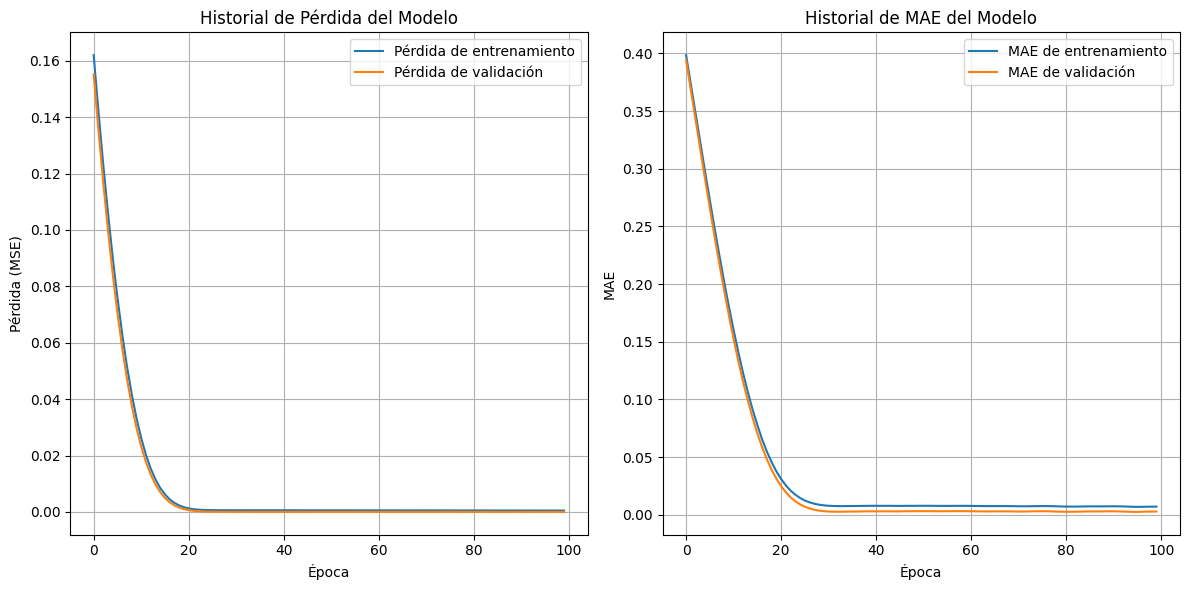

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


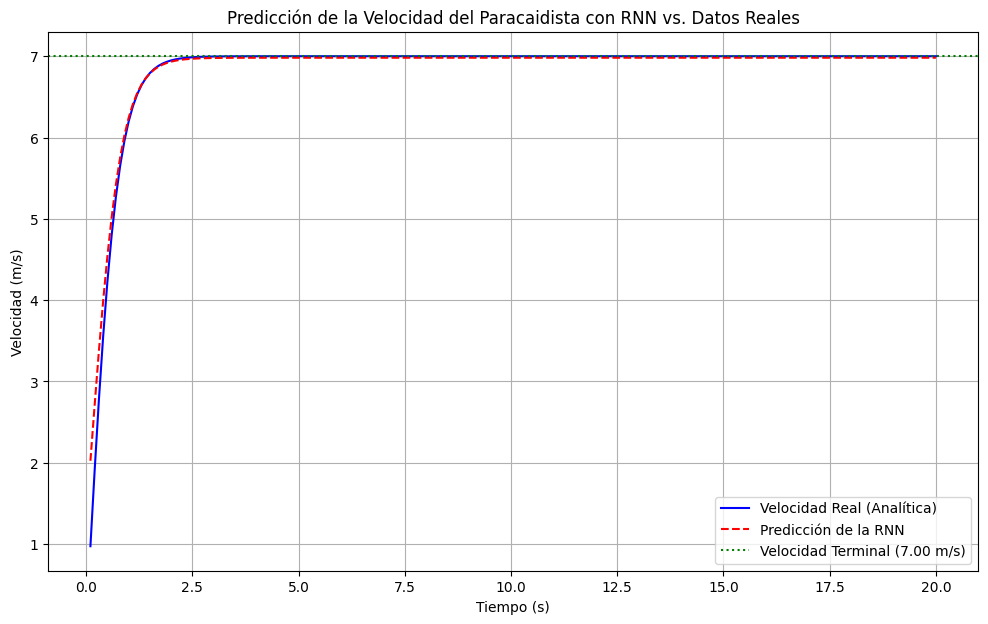

In [ ]:
# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Preparación de los datos para la RNN ---
X = entrada2['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada2['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una SimpleRNN con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (RNN) ---
modelrelu = Sequential()
modelrelu.add(SimpleRNN(10, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
modelrelu.add(Dense(1))

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelrelu.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelrelu.summary()

# --- Entrenamiento del modelo ---
history = modelrelu.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelrelu.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelrelu.predict(X_scaled) # Corregido: Usar modelrelu
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad2[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la RNN', color='red', linestyle='--')
plt.axhline(y=vt2, color='green', linestyle=':', label=f'Velocidad Terminal ({vt2:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con RNN vs. Datos Reales para M=60kg')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

#Modelo Simple RNN para $M=30kg$

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - loss: 1.2618 - mean_absolute_error: 1.1174 - val_loss: 1.2523 - val_mean_absolute_error: 1.1191
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1911 - mean_absolute_error: 1.0809 - val_loss: 1.2008 - val_mean_absolute_error: 1.0958
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1456 - mean_absolute_error: 1.0598 - val_loss: 1.1505 - val_mean_absolute_error: 1.0726
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0893 - mean_absolute_error: 1.0339 - val_loss: 1.1014 - val_mean_absolute_error: 1.0495
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0497 - mean_absolute_error: 1.0146 - val_loss: 1.0537 - val_mean_absolute_error: 1.0265
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0110 - mean_absolute_error: 0.9998 - val_loss: 1.0073 - val_mean_absolute_error: 1.0036
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9591 - mean_absolute_error: 0.9712 - val_loss: 0.96

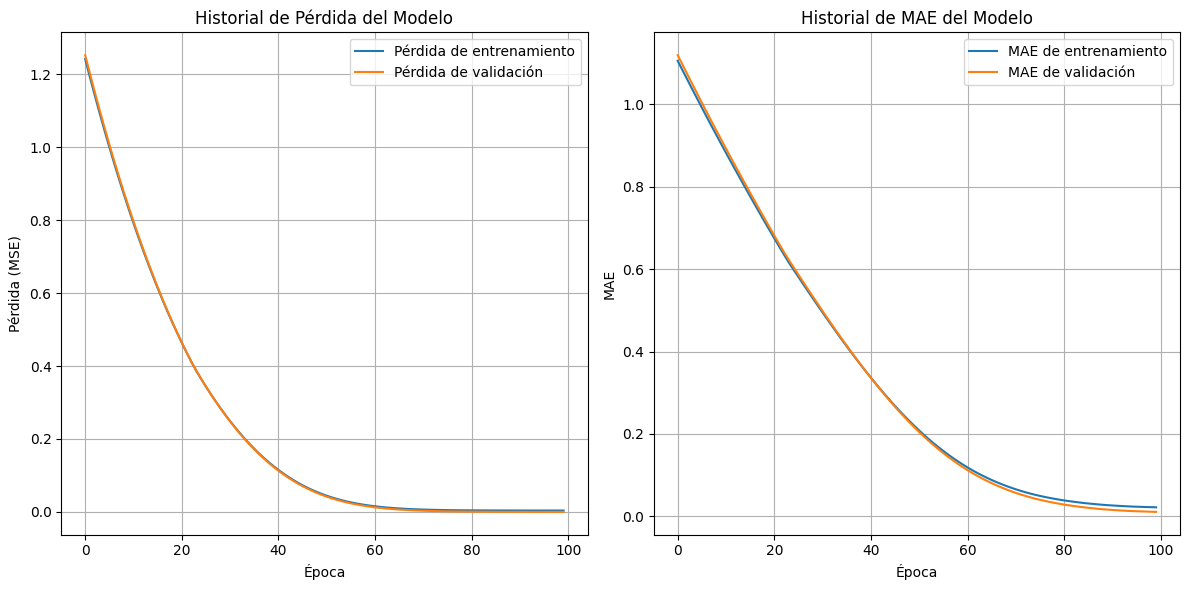

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


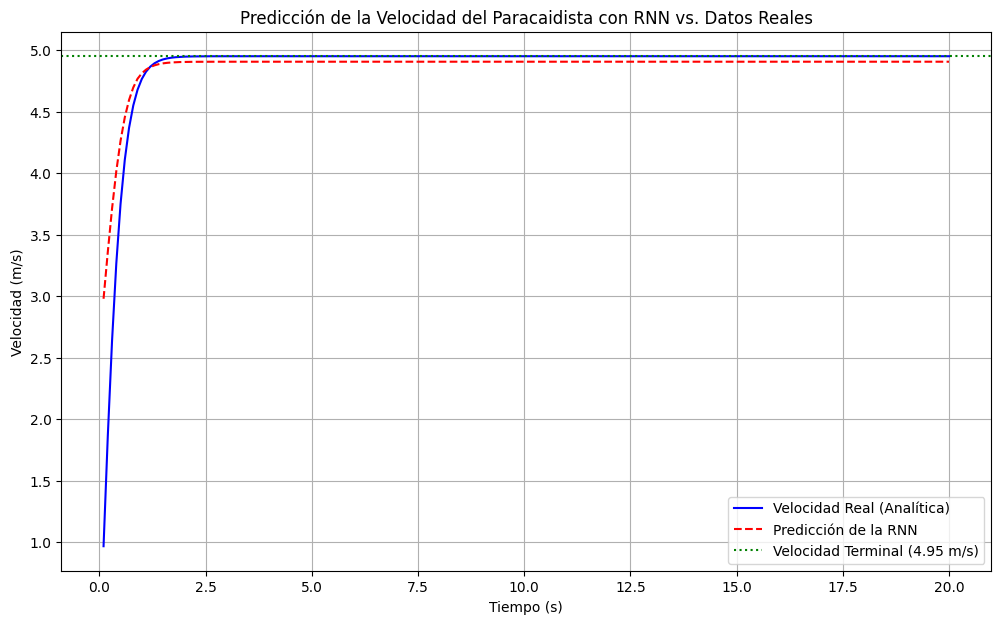

In [ ]:
# --- Crear el DataFrame ---
entrada = pd.DataFrame({'Tiempo (s)': tiempo, 'Velocidad (m/s)': velocidad})

# --- Preparación de los datos para la RNN ---
X = entrada3['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada3['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una SimpleRNN con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (RNN) ---
modelrelu = Sequential()
modelrelu.add(SimpleRNN(10, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
modelrelu.add(Dense(1))

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelrelu.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelrelu.summary()

# --- Entrenamiento del modelo ---
history = modelrelu.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelrelu.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelrelu.predict(X_scaled) # Corregido: Usar modelrelu
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad3[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la RNN', color='red', linestyle='--')
plt.axhline(y=vt3, color='green', linestyle=':', label=f'Velocidad Terminal ({vt3:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con RNN vs. Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

#Modelo LSTM para $M=100kg$

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.8603 - mean_absolute_error: 0.9181 - val_loss: 0.8393 - val_mean_absolute_error: 0.9160
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7901 - mean_absolute_error: 0.8761 - val_loss: 0.7776 - val_mean_absolute_error: 0.8816
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.7328 - mean_absolute_error: 0.8442 - val_loss: 0.7175 - val_mean_absolute_error: 0.8468
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6804 - mean_absolute_error: 0.8165 - val_loss: 0.6590 - val_mean_absolute_error: 0.8116
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6128 - mean_absolute_error: 0.7709 - val_loss: 0.6024 - val_mean_absolute_error: 0.7759
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5571 - mean_absolute_error: 0.7330 - val_loss: 0.5471 - val_mean_absolute_error: 0.7395
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5100 - mean_absolute_error: 0.7032 - val_loss: 0.49

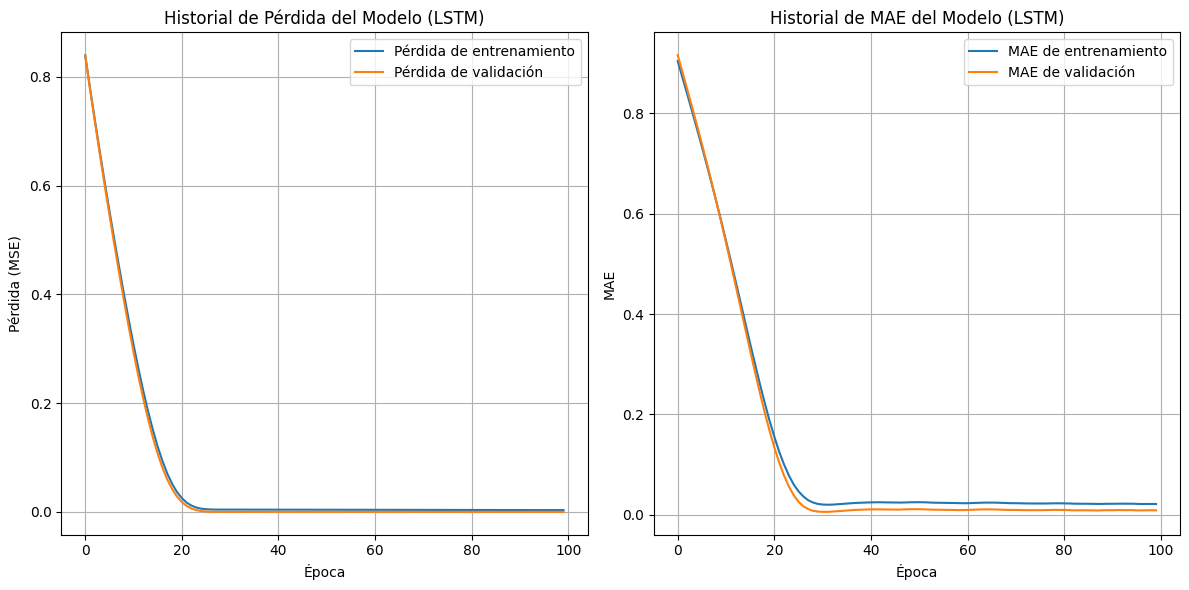

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


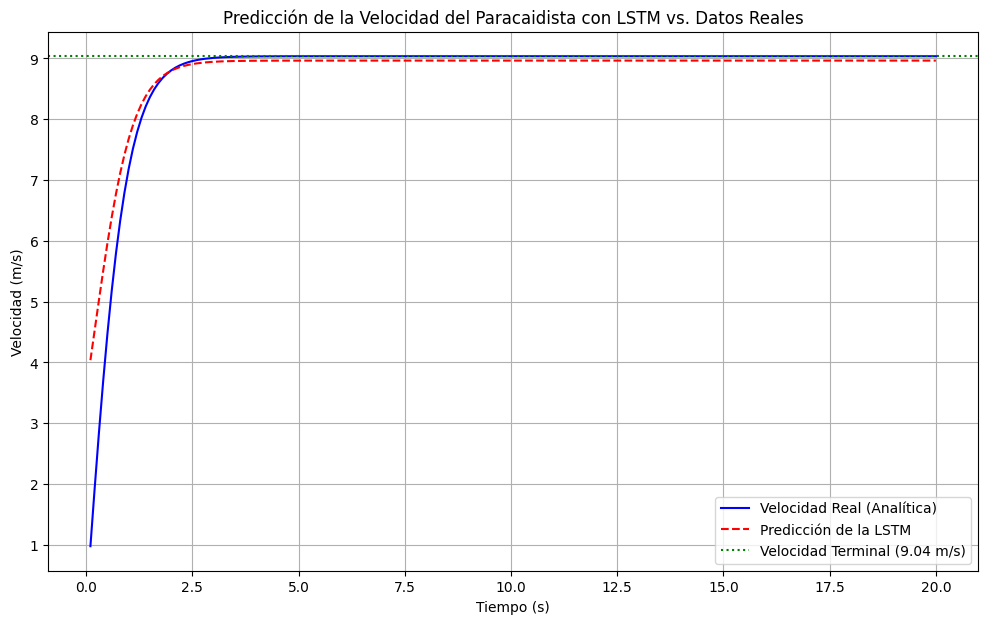

In [ ]:
# --- Preparación de los datos para la RNN ---
X = entrada1['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada1['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una LSTM con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (LSTM) ---
modelLSTM = Sequential()
# Nota: La activación 'tanh' en la capa LSTM interna es común y a menudo efectiva.
# El punto crítico es la capa de salida.
modelLSTM.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
modelLSTM.add(Dense(1)) # ¡Importante: SIN FUNCIÓN DE ACTIVACIÓN en la capa de salida para regresión!

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelLSTM.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelLSTM.summary()

# --- Entrenamiento del modelo ---
# Aumentar las épocas para permitir que la LSTM aprenda mejor
history = modelLSTM.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelLSTM.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento (Pérdida y MAE) ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelLSTM.predict(X_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad1[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la LSTM', color='red', linestyle='--')
plt.axhline(y=vt1, color='green', linestyle=':', label=f'Velocidad Terminal ({vt1:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con LSTM vs. Datos Reales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

#Modelo LSTM Para $M=60kg

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.9173 - mean_absolute_error: 0.9505 - val_loss: 0.9067 - val_mean_absolute_error: 0.9522
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8587 - mean_absolute_error: 0.9174 - val_loss: 0.8472 - val_mean_absolute_error: 0.9204
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7891 - mean_absolute_error: 0.8773 - val_loss: 0.7896 - val_mean_absolute_error: 0.8886
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7428 - mean_absolute_error: 0.8520 - val_loss: 0.7336 - val_mean_absolute_error: 0.8565
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6919 - mean_absolute_error: 0.8223 - val_loss: 0.6793 - val_mean_absolute_error: 0.8241
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6335 - mean_absolute_error: 0.7860 - val_loss: 0.6262 - val_mean_absolute_error: 0.7913
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5800 - mean_absolute_error: 0.7488 - val_loss: 0.574

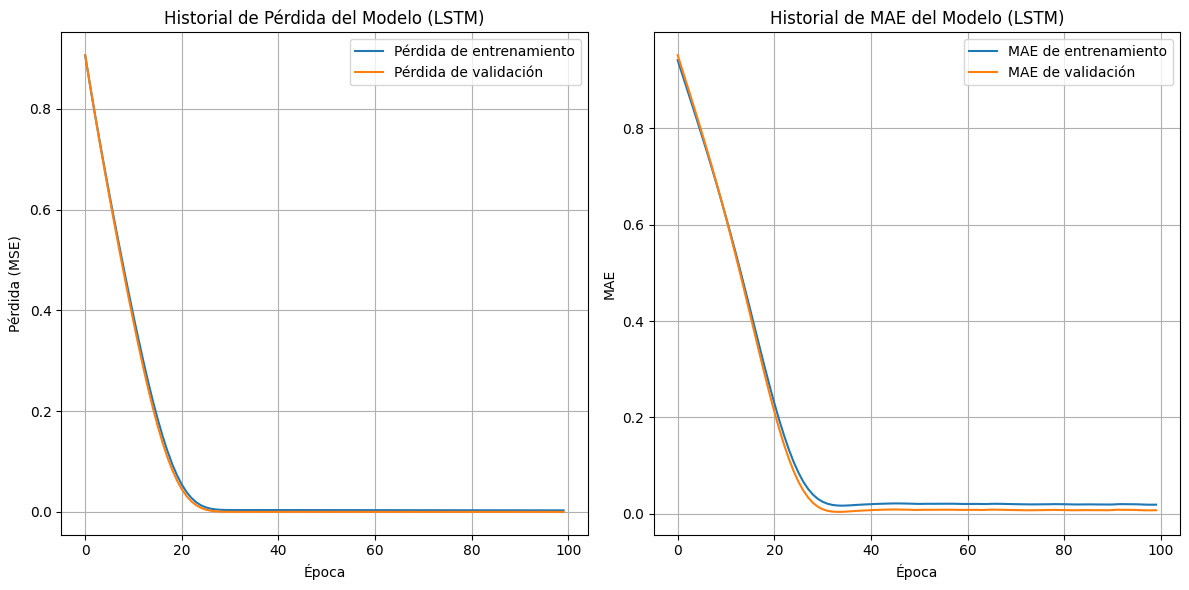

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


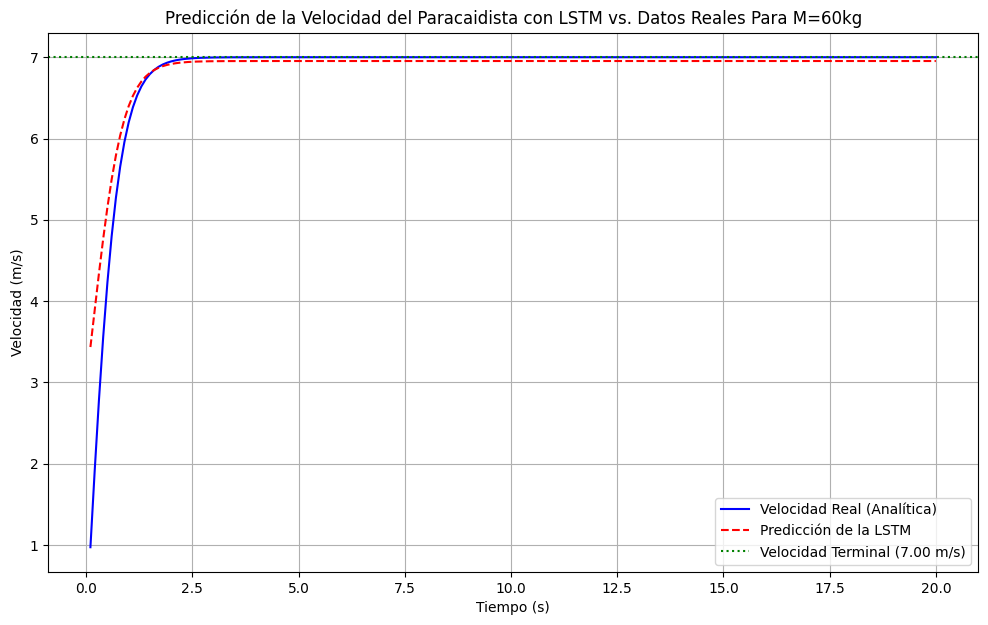

In [ ]:
# --- Preparación de los datos para la RNN ---
X = entrada2['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada2['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una LSTM con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (LSTM) ---
modelLSTM = Sequential()
# Nota: La activación 'tanh' en la capa LSTM interna es común y a menudo efectiva.
# El punto crítico es la capa de salida.
modelLSTM.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
modelLSTM.add(Dense(1)) # ¡Importante: SIN FUNCIÓN DE ACTIVACIÓN en la capa de salida para regresión!

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelLSTM.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelLSTM.summary()

# --- Entrenamiento del modelo ---
# Aumentar las épocas para permitir que la LSTM aprenda mejor
history = modelLSTM.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelLSTM.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento (Pérdida y MAE) ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelLSTM.predict(X_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad2[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la LSTM', color='red', linestyle='--')
plt.axhline(y=vt2, color='green', linestyle=':', label=f'Velocidad Terminal ({vt2:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con LSTM vs. Datos Reales Para M=60kg')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

#Modelo LSTM Para $M=30kg$


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.9182 - mean_absolute_error: 0.9535 - val_loss: 0.8992 - val_mean_absolute_error: 0.9482
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8586 - mean_absolute_error: 0.9198 - val_loss: 0.8439 - val_mean_absolute_error: 0.9186
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7995 - mean_absolute_error: 0.8868 - val_loss: 0.7896 - val_mean_absolute_error: 0.8886
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7517 - mean_absolute_error: 0.8606 - val_loss: 0.7361 - val_mean_absolute_error: 0.8580
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7003 - mean_absolute_error: 0.8313 - val_loss: 0.6833 - val_mean_absolute_error: 0.8266
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.6507 - mean_absolute_error: 0.8016 - val_loss: 0.6309 - val_mean_absolute_error: 0.7943
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6020 - mean_absolute_error: 0.7707 - val_loss: 0.579

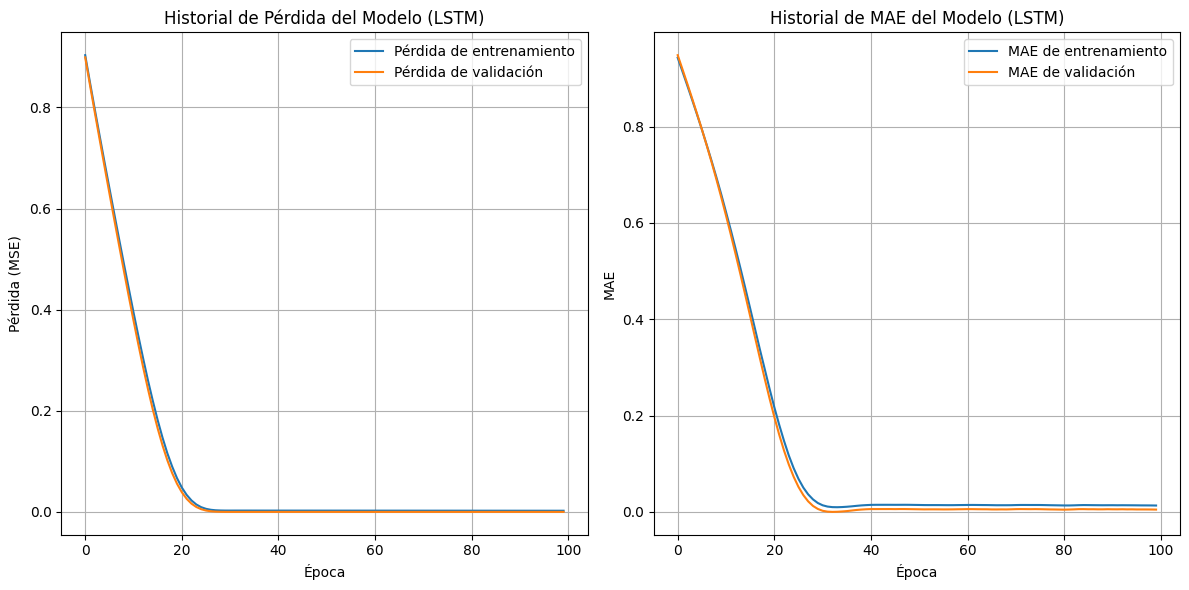

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


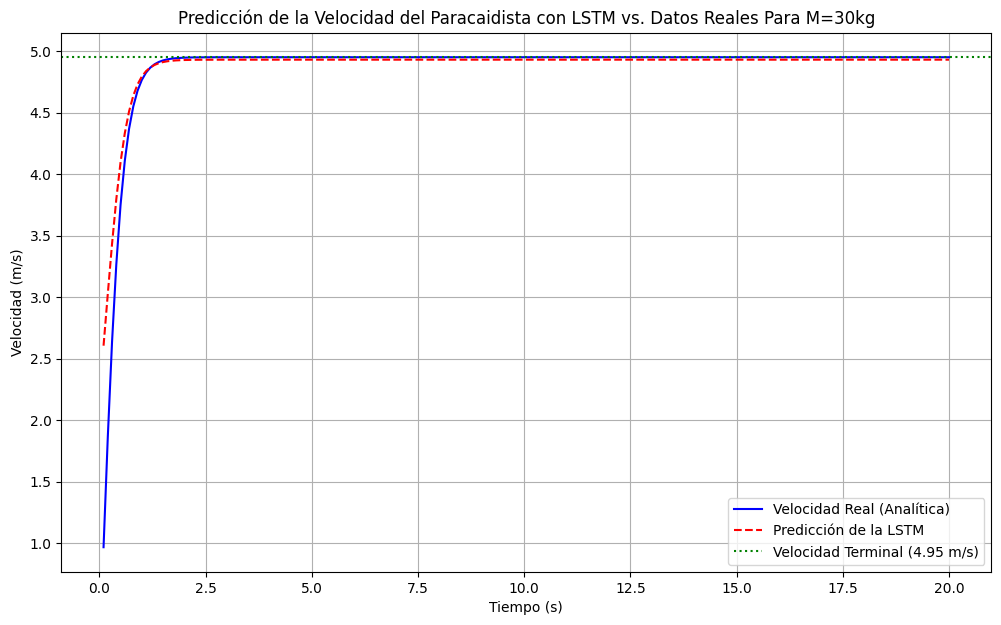

In [ ]:
# --- Preparación de los datos para la RNN ---
X = entrada3['Velocidad (m/s)'].values[:-1] # Todos los valores excepto el último
y = entrada3['Velocidad (m/s)'].values[1:]  # Todos los valores excepto el primero

# Reshape para que X sea (número_de_muestras, número_de_pasos_temporales, número_de_características)
# Para una LSTM con una sola característica (velocidad) y un solo paso temporal
X = X.reshape(-1, 1, 1)
y = y.reshape(-1, 1)

# Normalización de los datos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X.reshape(-1, 1)).reshape(-1, 1, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# --- Construcción de la Red Neuronal Recurrente (LSTM) ---
modelLSTM = Sequential()
# Nota: La activación 'tanh' en la capa LSTM interna es común y a menudo efectiva.
# El punto crítico es la capa de salida.
modelLSTM.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
modelLSTM.add(Dense(1)) # ¡Importante: SIN FUNCIÓN DE ACTIVACIÓN en la capa de salida para regresión!

# Compilación del modelo
# Agregamos 'mae' a las métricas para monitorearlo durante el entrenamiento
modelLSTM.compile(optimizer='adam', loss='mean_squared_error', metrics=[MeanAbsoluteError()])

# Resumen del modelo
modelLSTM.summary()

# --- Entrenamiento del modelo ---
# Aumentar las épocas para permitir que la LSTM aprenda mejor
history = modelLSTM.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# --- Evaluación del modelo ---
# evaluate devuelve la pérdida y las métricas que definiste al compilar
eval_results = modelLSTM.evaluate(X_test, y_test, verbose=0)
loss = eval_results[0]
mae = eval_results[1] # El MAE es el segundo elemento en los resultados de evaluación

print(f'\nError cuadrático medio en el conjunto de prueba: {loss:.4f}')
print(f'Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}')

# --- Visualización del historial de entrenamiento (Pérdida y MAE) ---
plt.figure(figsize=(12, 6))

# Subplot para la pérdida
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de Pérdida del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

# Subplot para el MAE
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['mean_absolute_error'], label='MAE de entrenamiento')
plt.plot(history.history['val_mean_absolute_error'], label='MAE de validación')
plt.title('Historial de MAE del Modelo (LSTM)')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para evitar superposiciones
plt.show()

# --- Realizar predicciones ---
predictions_scaled = modelLSTM.predict(X_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Comparar predicciones con los datos reales
plt.figure(figsize=(12, 7))
plt.plot(tiempo[1:], velocidad3[1:], label='Velocidad Real (Analítica)', color='blue')
plt.plot(tiempo[1:], predictions.flatten(), label='Predicción de la LSTM', color='red', linestyle='--')
plt.axhline(y=vt3, color='green', linestyle=':', label=f'Velocidad Terminal ({vt3:.2f} m/s)')
plt.title('Predicción de la Velocidad del Paracaidista con LSTM vs. Datos Reales Para M=30kg')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

Se puede observar que ambas redes replican un comportamiento similar incluso al cambiar parametros del problema.